# Getting Started with JAXNRSur

This notebook introduces the core JAXNRSur API for generating gravitational-wave waveforms from numerical relativity surrogates. It covers model instantiation, waveform evaluation in geometric and physical units, automatic differentiation, and batch computation with `vmap`.

## Setup

JAX defaults to 32-bit floats, which is insufficient for accurate surrogate evaluation. Always enable 64-bit precision before importing JAX.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)  # must be set before any JAX computation

import jax.numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt
from jaxnrsur.NRHybSur3dq8 import NRHybSur3dq8Model

## Geometric-unit waveform

The low-level model classes (`NRHybSur3dq8Model`, `NRSur7dq4Model`) operate in geometric units. The time array is in units of total mass $M$, and the returned strains $h_{+,\times}$ are scaled by $r/M$ (dimensionless, distance- and mass-independent).

For NRHybSur3dq8 the parameter vector is `[q, chi1z, chi2z]` (aligned spins). Here we use a GW150914-like mass ratio and small spins.

In [2]:
time = jnp.linspace(-1000, 100, 100000)
params = jnp.array([1.1, 0.1, 0.1])  # [q, chi1z, chi2z]
model = NRHybSur3dq8Model()

Try loading file from cache
Cache found and loading data


Call the model. `theta=phi=0` (the defaults) correspond to a face-on, overhead binary.

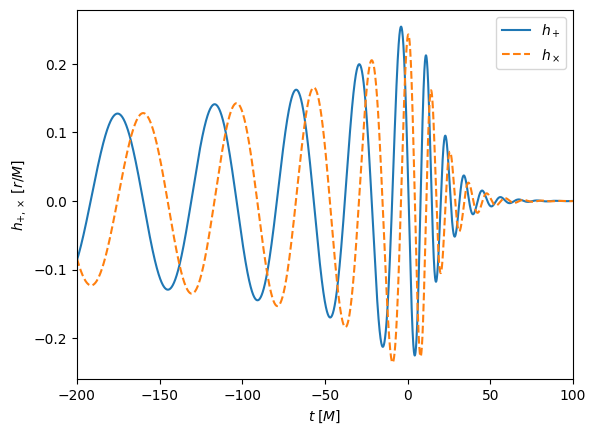

In [3]:
hp, hc = model(time, params)

plt.plot(time, hp, label=r"$h_+$")
plt.plot(time, hc, label=r"$h_\times$", ls="--")
plt.xlabel(r"$t\;[M]$")
plt.ylabel(r"$h_{+,\times}\;[r/M]$")
plt.xlim(-200, 100)
plt.legend()
plt.show()

## Automatic differentiation

Because JAXNRSur is built on JAX, all model evaluations are differentiable. Use `equinox.filter_grad` (or `jax.grad`) to compute gradients with respect to any source parameter.

In [4]:
def total_power(params):
    hp, hc = model(time, params)
    return jnp.sum(hp**2 + hc**2)

grad = eqx.filter_jit(eqx.filter_grad(total_power))
print(grad(params))  # gradient w.r.t. [q, chi1z, chi2z]

[-101.12266948  123.97841812  108.50793015]


## Batch evaluation with vmap

Use `equinox.filter_vmap` to evaluate the model over a batch of parameter vectors in a single vectorized call — no Python loop needed.

In [5]:
params_batch = jnp.repeat(params[None], 10, axis=0)  # (10, 3)
hp_batch, hc_batch = eqx.filter_jit(
    eqx.filter_vmap(model, in_axes=(None, 0))
)(time, params_batch)
print("batch output shape:", hp_batch.shape)  # (10, 100000)

batch output shape: (10, 100000)


## Physical-unit waveform with the `JAXNRSur` wrapper

The `JAXNRSur` class wraps any low-level model and scales the output to SI units given a total mass (solar masses) and luminosity distance (Mpc). It also optionally applies a start-of-signal window and a low-frequency cutoff.

In [6]:
from jaxnrsur import JAXNRSur

# segment_length and sampling_rate are required for get_waveform_fd
jaxnrsur = JAXNRSur(model, alpha_window=0.1, segment_length=4.0, sampling_rate=4096)

In [7]:
# params = [M_tot (Msun), dist_mpc, inclination (rad), phase_c (rad), q, chi1z, chi2z]
params_si = jnp.array([60.0, 400.0, 0.4, 0.0, 1.1, 0.1, 0.1])
time_si = jnp.linspace(-4.0, 0.0, 4 * 4096)  # SI seconds
hp, hc = jaxnrsur.get_waveform_td(time_si, params_si)

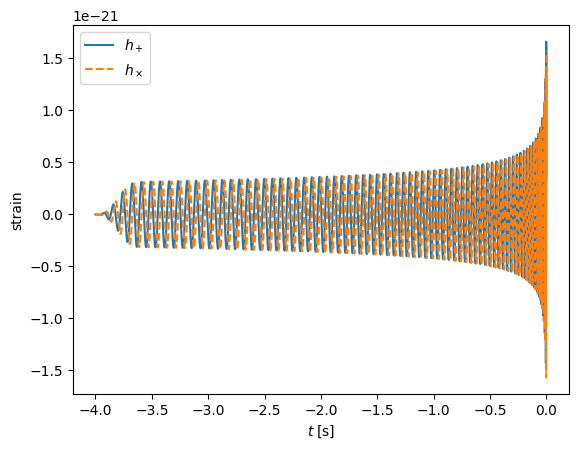

In [8]:
plt.plot(time_si, hp, label=r"$h_+$")
plt.plot(time_si, hc, label=r"$h_\times$", ls="--")
plt.xlabel(r"$t\;[\mathrm{s}]$")
plt.ylabel("strain")
plt.legend()
plt.show()